In [1]:
import ROOT
from scipy import interpolate as interpolate
from scipy.stats import norm
import numpy as np
from utils import NonUniformStat, append_to_dict
import json
from matplotlib import pyplot as plt

In [2]:
BIAS = {}

with open("bias_dictionary.json", "r", encoding="utf-8") as f:
    BIAS = json.load(f)

tot_event, Dmu, Dsigma, nB_value = 0,0,0,0
#distribution = [169, 162, 188, 133, 121, 130, 162, 137, 195, 171, 154]

# load configuration file and read the configurations
with open("config.txt", 'r') as file:
    for line in file:
        line = line.strip()
        line = line.replace(" ","")
        if not ("#" in line):
            print(line)
        if not line:
            continue
        if 'Ntot' in line:
            key, value = line.split('=')
            tot_event = int(value)
        if 'nB_val' in line:
            key, value = line.split('=')
            nB_val = int(value)
        if 'Dmu' in line:
            key, value = line.split('=')
            Dmu = float(value)
        if 'Dsigma' in line:
            key, value = line.split('=')
            Dsigma = float(value)
        if 'real_gravity' in line:
            key, value = line.split('=')
            real_gravity = float(value)
        if 'Ntoys' in line:
            key, value = line.split('=')
            Ntoys = int(value)



Dmu=+0.02
Dsigma=0.08
K=0.85
real_gravity=-10
Ntot=1100
nB_val=7
Ntoys=1000
pfraction=0.5


In [3]:
Dmu    = Dmu
Dsigma = Dsigma
L      = 4
print(Dmu)

0.02


In [4]:
# Parameters
L = 2
Dsigma = 0.08


In [5]:
def sample_steep_region(n=200, k=1, a=1, g = -10):
    """
    Campiona n punti nella regione ripida di tanh(kx).
    a definisce quanto 'larga' è la regione ripida (in unità di 1/k).
    """
    x_min = -a / k + g/10
    x_max = +a / k + g/10
    xs = np.linspace(x_min, x_max, n) * 10
    return xs, x_min, x_max

In [6]:
BIAS = {}
#biasList = np.linspace( (real_gravity/10 - L/2)*10, (real_gravity/10 + L/2)*10, 7)

# a = 1.84 correspond to +0.95 for up and -0.95 for down
biasList, xmin, xmax = sample_steep_region(7, L, a = 1.84, g = real_gravity)
print(f"Interval region: [{xmin:.2f},{xmax:.2f}]")
print(f"bias list is {biasList}")

for bias in biasList:
    BIAS.update({f"{(bias/10):.1f}g" : int(bias)})

print(BIAS)

weights = {} # define the dictionary containing the statistics
for key, value in BIAS.items():
    weights.update( {key: int(tot_event/len(BIAS.values())) })

Interval region: [-1.92,-0.08]
bias list is [-19.2        -16.13333333 -13.06666667 -10.          -6.93333333
  -3.86666667  -0.8       ]
{'-1.9g': -19, '-1.6g': -16, '-1.3g': -13, '-1.0g': -10, '-0.7g': -6, '-0.4g': -3, '-0.1g': 0}


# Spline approximated with LINEAR SLOPE

In [7]:
# def scurve_model(x, L, g):
#     result = 0
#     if((-L/2 + g) < x and x < ( L/2 + g)):
#         result = 2/L * (x - g)
#     elif((-L/2 +g) >= x):
#         result = -.99
#     elif(x >= ( L/2 + g )):
#         result = +.99
#     return result

def scurve_model(x, L, g):
    return np.tanh(L * (x - g))

print("linear scurve evaluated at -2 : %.1f" % scurve_model(-2,2,-1))
print("linear scurve evaluated at -1.5 : %.1f" % scurve_model(-1.5,2,-1))
print("linear scurve evaluated at -1 : %.1f" % scurve_model(-1,2,-1))
print("linear scurve evaluated at -.5 : %.1f" % scurve_model(-.5,2,-1))
print("linear scurve evaluated at -2 : %.1f" % scurve_model(-2,2,-1))
print("linear scurve evaluated at 0 : %.1f"  % scurve_model(0,2,-1))
print("linear scurve evaluated at 1 : %.1f"  % scurve_model(1,2,-1))
print("linear scurve evaluated at 1 : %.1f"  % scurve_model(10,2,-1))

linear scurve evaluated at -2 : -1.0
linear scurve evaluated at -1.5 : -0.8
linear scurve evaluated at -1 : 0.0
linear scurve evaluated at -.5 : 0.8
linear scurve evaluated at -2 : -1.0
linear scurve evaluated at 0 : 1.0
linear scurve evaluated at 1 : 1.0
linear scurve evaluated at 1 : 1.0


In [8]:
import csv

# ===  generate the True Asymemtry from Simulation
ASYMMETRY_TRUE = {}
for key, value in BIAS.items():
    ASYMMETRY_TRUE.update({key : float(scurve_model(value/10, L, real_gravity/10))})
    
print(ASYMMETRY_TRUE)

# Create simulation file
rows = []
for bias in np.linspace(-11, 9, 200):
    rows.append([bias, scurve_model(bias, L, real_gravity/10)])  # ogni riga = [bias, valore]
    print(bias, scurve_model(bias, L, 1) )

# save simulation file
with open("simulation.csv", "w", newline="") as f:
    writer = csv.writer(f)
    #writer.writerow(["bias", "scurve"])   # intestazioni opzionali
    writer.writerows(rows)

{'-1.9g': -0.9468060128462683, '-1.6g': -0.8336546070121553, '-1.3g': -0.5370495669980353, '-1.0g': 0.0, '-0.7g': 0.664036770267849, '-0.4g': 0.8853516482022624, '-0.1g': 0.9640275800758169}
-11.0 -1.0
-10.899497487437186 -1.0
-10.798994974874372 -1.0
-10.698492462311558 -1.0
-10.597989949748744 -1.0
-10.49748743718593 -1.0
-10.396984924623116 -1.0
-10.296482412060302 -1.0
-10.195979899497488 -1.0
-10.095477386934673 -1.0
-9.99497487437186 -1.0
-9.894472361809045 -1.0
-9.793969849246231 -1.0
-9.693467336683417 -1.0
-9.592964824120603 -1.0
-9.492462311557789 -1.0
-9.391959798994975 -1.0
-9.291457286432161 -1.0
-9.190954773869347 -1.0
-9.090452261306533 -1.0
-8.989949748743719 -1.0
-8.889447236180905 -1.0
-8.78894472361809 -1.0
-8.688442211055277 -1.0
-8.587939698492463 -1.0
-8.487437185929648 -0.9999999999999999
-8.386934673366834 -0.9999999999999999
-8.28643216080402 -0.9999999999999999
-8.185929648241206 -0.9999999999999998
-8.085427135678392 -0.9999999999999997
-7.984924623115578 -0.

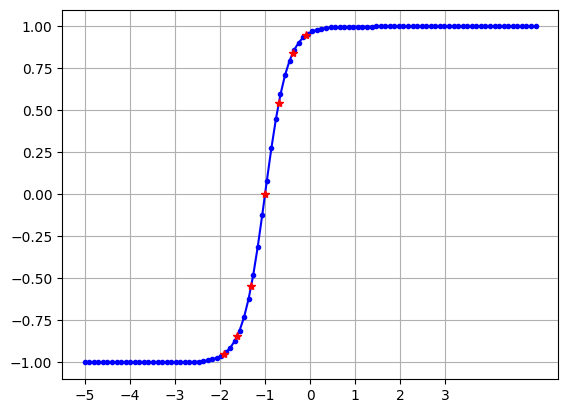

In [9]:
plt.figure(1)
xpoints = np.linspace(-5,5,100)
ypoints = [scurve_model(item, L, real_gravity/10) for item in xpoints]
plt.errorbar(xpoints, ypoints, marker = '.', color = 'blue')
plt.xticks([-5,-4,-3,-2,-1,0,1,2,3])
ypoints = [scurve_model(item/10, L, real_gravity/10) for item in biasList]
xpoints = np.array(biasList)/10
plt.errorbar(xpoints, ypoints, linestyle = "" ,marker = "*", color = "red")
plt.grid()
plt.savefig(f"scurve_L_{L}.png")

# Open The Workspace with the PDFs

In [10]:
f = ROOT.TFile("analysis_output/workspace.root")
w = f.Get("w")
w.Print("v")

w['c_pbarDn_1'].setVal(1.0); w['c_pbarDn_1'].setConstant(True)
w['c_pbarUp_1'].setVal(1.0); w['c_pbarUp_1'].setConstant(True)


RooWorkspace(w) w contents

variables
---------
(Z,biaskey,c_pbarDn_1,c_pbarDn_2,c_pbarUp_1,c_pbarUp_2,evtype)

p.d.f.s
-------
RooHistPdf::hpdf_pbarDn_1[ pdfObs=(Z) ] = 0.0121951
RooHistPdf::hpdf_pbarDn_2[ pdfObs=(Z) ] = 0.0121951
RooHistPdf::hpdf_pbarUp_1[ pdfObs=(Z) ] = 0.844512
RooHistPdf::hpdf_pbarUp_2[ pdfObs=(Z) ] = 0.844512
RooHistPdf::pdf_cosm[ pdfObs=(Z) ] = 1.8628
RooAddPdf::pdf_pbarDn[ c_pbarDn_1 * hpdf_pbarDn_1 + [%] * hpdf_pbarDn_2 ] = 0.0121951/1
RooAddPdf::pdf_pbarUp[ c_pbarUp_1 * hpdf_pbarUp_1 + [%] * hpdf_pbarUp_2 ] = 0.844512/1

datasets
--------
RooDataHist::rdhbin_pbarUp1(Z)
RooDataHist::rdhbin_pbarUp2(Z)
RooDataHist::rdhbin_pbarDn1(Z)
RooDataHist::rdhbin_pbarDn2(Z)

embedded datasets (in pdfs and functions)
-----------------------------------------
RooDataHist::rhcosm(Z)



In [11]:
Z = w['Z']
zframe = Z.frame(Title = "Z Distributions, Templates")
w['pdf_pbarUp'].plotOn(zframe, ROOT.RooFit.LineColor(ROOT.kRed))
w['pdf_pbarDn'].plotOn(zframe, ROOT.RooFit.LineColor(ROOT.kBlue))
w['pdf_cosm'].plotOn(zframe, ROOT.RooFit.LineColor(ROOT.kGreen))

c = ROOT.TCanvas("pdfs_templates", "pdfs_templates", 600, 600)
ROOT.gPad.SetLeftMargin(0.15)
zframe.GetYaxis().SetTitleOffset(1.4)
zframe.Draw()
c.Draw()

# Create the RooDataSet

In [12]:
BiasCategory = ROOT.RooCategory("secondCategory", "a second category", BIAS)
BiasCategory.Print("v")

#dataset = ROOT.RooDataSet("data","data", ROOT.RooArgSet(Z,BiasCategory))

--- RooAbsArg ---
  Value State: clean
  Shape State: clean
  Attributes: 
  Address: 0x6422bb417470
  Clients: 
  Servers: 
  Proxies: 
--- RooAbsCategory ---
  Value = -19 "-1.9g)
  Possible states:
    -0.1g	0
    -0.4g	-3
    -0.7g	-6
    -1.0g	-10
    -1.3g	-13
    -1.6g	-16
    -1.9g	-19


In [13]:
simModelBase = ROOT.RooSimultaneous("model_base_simultaneous", "model for bias", BiasCategory)

# 2. Crea un mapping da categoria (es. "-1.0g") a PDF personalizzato

pdf_per_categoria = {} # senno muoiono

for category, weight in weights.items():
    print(f"Setting up PDF for category: {category}")
    
    # Calcolo degli eventi Up/Down
    Nup   = 0.5 * weight * (1 - ASYMMETRY_TRUE[category])
    Ndown = 0.5 * weight * (1 + ASYMMETRY_TRUE[category])
    
    # Costanti per RooAddPdf
    nup_const = ROOT.RooFit.RooConst(Nup)
    ndwn_const = ROOT.RooFit.RooConst(Ndown)
    
    # PDF composita per questa categoria
    model_i = ROOT.RooAddPdf(f"pdf_{category}", f"pdf_{category}",
                             ROOT.RooArgList(w['pdf_pbarUp'], w['pdf_pbarDn']),
                             ROOT.RooArgList(nup_const, ndwn_const))
    pdf_per_categoria[category] = model_i
    
    # Aggiungila alla simultanea
    simModelBase.addPdf(model_i, category)

Setting up PDF for category: -1.9g
Setting up PDF for category: -1.6g
Setting up PDF for category: -1.3g
Setting up PDF for category: -1.0g
Setting up PDF for category: -0.7g
Setting up PDF for category: -0.4g
Setting up PDF for category: -0.1g


In [14]:
# Generazione separata per ciascuna categoria
dataset = simModelBase.generate(ROOT.RooArgSet(Z, BiasCategory), ROOT.RooFit.Extended())
dataset.Print("v")

DataStore hmaster (hmaster)
  Contains 14 entries
  Observables: 
    1)               Z = -450  L(-875.35 - -219.35) B(2)  "Z"
    2)  secondCategory = -1.9g(idx = -19)
  "a second category"


In [15]:
ttable = dataset.table(BiasCategory)
ttable.Print("v")


  Table secondCategory : hmaster
  +-------+-----+
  | -1.9g | 146 |
  | -1.6g | 177 |
  | -1.3g | 138 |
  | -1.0g | 145 |
  | -0.7g | 170 |
  | -0.4g | 168 |
  | -0.1g | 168 |
  +-------+-----+



In [16]:
c1 = ROOT.TCanvas("data_plot", "data_plot", 800, 800)

zframe1 = Z.frame( ROOT.RooFit.Bins(18), Title = "Plot of Z data")
dataset.plotOn(zframe1, ROOT.RooFit.Cut('secondCategory == -30'), ROOT.RooFit.MarkerColor(ROOT.kBlue),  ROOT.RooFit.Name("cat_-30"))
dataset.plotOn(zframe1, ROOT.RooFit.Cut('secondCategory == -20'), ROOT.RooFit.MarkerColor(ROOT.kRed),   ROOT.RooFit.Name("cat_-20"))
dataset.plotOn(zframe1, ROOT.RooFit.Cut('secondCategory == 30'), ROOT.RooFit.MarkerColor(ROOT.kGreen),  ROOT.RooFit.Name("cat_+30"))
#dataset.plotOn(zframe1, ROOT.RooFit.Cut('secondCategory == +20'), ROOT.RooFit.MarkerColor(6),   ROOT.RooFit.Name("cat_-20"))
#w['model_base'].plotOn(zframe1)

#simModelBase.plotOn(zframe1, ROOT.RooFit.Slice(BiasCategory, "-3.0g") , ROOT.RooFit.ProjWData(ROOT.RooArgSet(BiasCategory), dataset) , ROOT.RooFit.LineColor(ROOT.kBlue))
#simModelBase.plotOn(zframe1, ROOT.RooFit.Slice(BiasCategory, "-2.0g") , ROOT.RooFit.ProjWData(ROOT.RooArgSet(BiasCategory), dataset) , ROOT.RooFit.LineColor(ROOT.kRed))
#simModelBase.plotOn(zframe1, ROOT.RooFit.Slice(BiasCategory, "+3.0g") , ROOT.RooFit.ProjWData(ROOT.RooArgSet(BiasCategory), dataset) , ROOT.RooFit.LineColor(ROOT.kGreen))

zframe1.Draw()

# Crea la legenda
legend = ROOT.TLegend(0.6, 0.7, 0.88, 0.88)  # x1,y1,x2,y2 in NDC (posizione)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.AddEntry(zframe1.findObject("cat_-30"), "-3.0g", "lep")
legend.AddEntry(zframe1.findObject("cat_-20"), "-2.0g", "lep")
legend.AddEntry(zframe1.findObject("cat_+30"), "+3.0g", "lep")
legend.Draw()

c1.Draw()

[#1] INFO:Plotting -- RooTreeData::plotOn: plotting 0 events out of 1112 total events
[#1] INFO:Plotting -- RooTreeData::plotOn: plotting 0 events out of 1112 total events
[#1] INFO:Plotting -- RooTreeData::plotOn: plotting 0 events out of 1112 total events


# Construction of the model for the Simulation

In [17]:
w.Import(BiasCategory) # <== Import the category inside the workspace

w.factory("S[100,50, 10000]")
w.factory("E[0.0, -1.5, 1.5]")
w.factory(f"D[{Dmu}, -0.8, 0.8]")

w.factory("SUM::model_base( Nup[30,10000] * pdf_pbarUp, Ndwn[30,1000] * pdf_pbarDn, nB[1, 200] * pdf_cosm)") # <<< Add pdf_cosm in the future
# A = (Ndwn - Nup)/(Ndwn + Nup)
w.factory(f"EDIT::model_MAGB(model_base, Nup=expr('0.5*S*(1-E)', S, E), Ndwn = expr('0.5*S*(1+E)', S, E))")

w.factory(f"Gaussian::Dconstr(D,{Dmu},{Dsigma})") # constrain on D, efficiency

w.factory("SIMCLONE::model_fit( model_MAGB, $SplitParam({S,E}, secondCategory ))") # Clone the Models

w.Print()

[#1] INFO:ObjectHandling -- RooWorkspace::import(w) importing RooCategory::secondCategory

RooWorkspace(w) w contents

variables
---------
(D,E,E_-0.1g,E_-0.4g,E_-0.7g,E_-1.0g,E_-1.3g,E_-1.6g,E_-1.9g,Ndwn,Nup,S,S_-0.1g,S_-0.4g,S_-0.7g,S_-1.0g,S_-1.3g,S_-1.6g,S_-1.9g,Z,biaskey,c_pbarDn_1,c_pbarDn_2,c_pbarUp_1,c_pbarUp_2,evtype,nB,secondCategory)

p.d.f.s
-------
RooGaussian::Dconstr[ x=D mean=0.02 sigma=0.08 ] = 1
RooHistPdf::hpdf_pbarDn_1[ pdfObs=(Z) ] = 0.0121951
RooHistPdf::hpdf_pbarDn_2[ pdfObs=(Z) ] = 0.0121951
RooHistPdf::hpdf_pbarUp_1[ pdfObs=(Z) ] = 0.844512
RooHistPdf::hpdf_pbarUp_2[ pdfObs=(Z) ] = 0.844512
RooAddPdf::model_MAGB[ model_MAGB_2 * pdf_pbarUp + model_MAGB_3 * pdf_pbarDn + nB * pdf_cosm ] = 1.14737/1
RooAddPdf::model_MAGB_-0.1g[ model_MAGB_2_-0.1g * pdf_pbarUp + model_MAGB_3_-0.1g * pdf_pbarDn + nB * pdf_cosm ] = 1.14737/1
RooAddPdf::model_MAGB_-0.4g[ model_MAGB_2_-0.4g * pdf_pbarUp + model_MAGB_3_-0.4g * pdf_pbarDn + nB * pdf_cosm ] = 1.14737/1
RooAddPdf::model_MAG

In [18]:
g = ROOT.TGraph("simulation.csv","%lg,%lg")
# create RooRealVar
w.factory('c[0,-30,30]')
#create RooRealVar
w.factory('scale[0.1]')
#w['scale'].setConstant(True)
w["nB"].setVal(nB_val)

# === Definisci la curva S come TF1 + RooTFnBinding ===
def Scurve_fn(x, p):
    # 10 is an offset of the simulation
    offset = -10
    bias = x[0]
    c = p[0]
    scale = p[1]
    D = p[2]
    return (g.Eval((x[0] - c + offset) * scale) - D)/(1 - g.Eval((x[0] - c + offset) * scale)*D)

# === Print values of the Scurve for a collection of biases ===
print("-"*8)
for key,value in BIAS.items():
    val = Scurve_fn([value], [w["c"].getVal(), w['scale'].getVal(), w['D'].getVal()])
    print(f"{key}| {value} | {w['c'].getVal()} | {val}")
print("-"*8)

# === create the RooFit model from the Scurve ===
Scurve_TF1 = ROOT.TF1("Scurve",Scurve_fn, -50, 50, 3) # not possible to put in workspace

cust = ROOT.RooCustomizer(w.pdf('model_fit'), "scurve");

vcat={}
nasy={}
for bkt, bias_val in BIAS.items():
    v = ROOT.RooRealVar(f"vat_{bkt}", "", bias_val)
    # Creo una funzione parametrica RooTFnBinding che connette il TF1 alla variabile 'v'
    # Il TF1 ha 3 parametri: c, scale, D — sono usati qui come [c, scale, D]
    asy = ROOT.RooTFnBinding(f"nasy_{bkt}", "", Scurve_TF1, v, [w['c'], w['scale'], w['D']])
    # Salvo queste entità nei dizionari
    vcat[bkt] = v
    nasy[bkt] = asy

    # Ottengo la variabile originale 'E_{bkt}' nel modello
    A = w.var(f'E_{bkt}')

    # Sostituisco E_{bkt} con la funzione curva S corrispondente
    cust.replaceArg(A, asy)

scurve_all = cust.build(True)

scurvemap = {}
for bkt, bias_val in BIAS.items():
    scurvemap.update({bkt : scurve_all.getPdf(bkt) })
    S = w.var(f'S_{bkt}')

    val = ttable.get(bkt)
    err = np.sqrt(val)
    
    #S.setMin(val-10*err)
    #S.setMax(val+10*err)
    S.setVal(val)
    print(f"setting  {val}  [{val - 10*err}  {val + 10*err}]")
    #S.setError(err)

scurve_fit = ROOT.RooSimultaneous("scurve_fit","scurve_fit", scurvemap, BiasCategory)

--------
-1.9g| -19 | 0.0 | -0.9990205289945941
-1.6g| -16 | 0.0 | -0.9967509653001462
-1.3g| -13 | 0.0 | -0.9892522450019776
-1.0g| -10 | 0.0 | -0.9647649394313713
-0.7g| -6 | 0.0 | -0.8371920868399894
-0.4g| -3 | 0.0 | -0.5473685472730021
-0.1g| 0 | 0.0 | -0.020000000000000014
--------


setting  146.0  [25.169540264054277  266.83045973594574]
setting  177.0  [43.95865304349928  310.0413469565007]
setting  138.0  [20.526598755292696  255.4734012447073]
setting  145.0  [24.584054212077035  265.41594578792296]
setting  170.0  [39.615951895947006  300.384048104053]
setting  168.0  [38.38518603184281  297.6148139681572]
setting  168.0  [38.38518603184281  297.6148139681572]


[#1] INFO:ObjectHandling -- RooCustomizer::build(model_fit): tree node E_-0.1g will be replaced by nasy_-0.1g
[#1] INFO:ObjectHandling -- RooCustomizer::build(model_fit): tree node E_-0.4g will be replaced by nasy_-0.4g
[#1] INFO:ObjectHandling -- RooCustomizer::build(model_fit): tree node E_-0.7g will be replaced by nasy_-0.7g
[#1] INFO:ObjectHandling -- RooCustomizer::build(model_fit): tree node E_-1.0g will be replaced by nasy_-1.0g
[#1] INFO:ObjectHandling -- RooCustomizer::build(model_fit): tree node E_-1.3g will be replaced by nasy_-1.3g
[#1] INFO:ObjectHandling -- RooCustomizer::build(model_fit): tree node E_-1.6g will be replaced by nasy_-1.6g
[#1] INFO:ObjectHandling -- RooCustomizer::build(model_fit): tree node E_-1.9g will be replaced by nasy_-1.9g
[#1] INFO:ObjectHandling -- RooCustomizer::build(model_fit) Branch node RooSimultaneous::model_fit cloned: depends on a replaced parameter
[#1] INFO:ObjectHandling -- RooCustomizer::build(model_fit) Branch node RooAddPdf::model_MA

In [19]:
w['D'].setConstant(True)

w['c'].setError(20)
result = scurve_fit.fitTo(dataset,
                 ROOT.RooFit.Minimizer("Minuit2","minimize"),
                 #ROOT.RooFit.ExternalConstraints(w['Dconstr']),
                 ROOT.RooFit.Strategy(2),
                 ROOT.RooFit.Save(),
                 ROOT.RooFit.Minos(w['c']))

c     = w.var('c')
scale = w.var('scale')
D = w.var('D')

# === 8. Risultati
print("\n=== RISULTATI DEL FIT ===")
print(f"c     = {c.getVal()*scale.getVal():.4f} ± {c.getError()*scale.getVal():.4f}; [{c.getErrorLo()*scale.getVal()},+{c.getErrorHi()*scale.getVal()}]")
print(f"scale = {scale.getVal():.4f} ± {scale.getError():.4f}")
print(f"D     = {D.getVal():.4f} ± {D.getError():.4f}")
print(f"fit status: {result.status()}")


=== RISULTATI DEL FIT ===
c     = -1.0006 ± 0.0256; [-0.025612796399893306,+0.02554224993035417]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0


[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Fitting -- RooAbsPdf::fitTo(scurve_fit) fixing normalization set for coefficient determination to observables in data
[#1] INFO:Fitting -- using CPU computation library compiled with -mavx2
[#1] INFO:Fitting -- RooAddition::defaultErrorLevel(nll_scurve_fit_hmaster) Summation contains a RooNLLVar, using its error level
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
Minuit2Minimizer: Minimize with max-calls 4500 convergence for edm < 1 strategy 2
Minuit2Minimizer : Valid minimum - status = 0
FVAL  = 4466.3952787428243
Edm   = 0.000155063427531898002
Nfcn  = 784
S_-0.1g	  = 167.106	 +/-  12.9639	(limited)
S_-0.4g	  = 167.243	 +/-  12.9647	(limited)
S_-0.7g	  = 169.07	 +/-  13.0414	(limited)
S_-1.0g	  = 143.956	 +/-  12.0398	(limited)
S_-1.3g	  = 136.868	 +/-  11.7453	(limited)
S_-1.6g	  = 175.948	 +/-  13.2954	(limited)
S_-1.9

Info in <Minuit2>: MnSeedGenerator Computing seed using NumericalGradient calculator
Info in <Minuit2>: MnSeedGenerator Initial state: FCN =       5133.947372 Edm =       2753.963158 NCalls =     37
Warning in <Minuit2>: MnPosDef Matrix forced pos-def by adding to diagonal 3.15661
Info in <Minuit2>: MnSeedGenerator run Hesse - Initial seeding state: 
  Minimum value : 5133.947372
  Edm           : 159474.9846
  Internal parameters:	[     -1.352562725     -1.352562725      -1.35071362     -1.375058943     -1.382430531     -1.344358725     -1.374028124                0     -1.221747644]	
  Internal gradient  :	[      46.63965765      91.54619361      180.3850092      208.1162589      177.2574276      66.92057337      57.38970311      3483.335666     -376.5239948]	
  Internal covariance matrix:
[[  0.00054961001  0.00095294566     0.00181568   0.0014638293  0.00092078075  0.00036460892  0.00033801147  -0.0014695819   -0.057341652]
 [  0.00095294566   0.0019857004   0.0036354545   0.002930

In [20]:
scurve_fit.getParameters(dataset).Print('v')

  1) 0x6422bbead0c0 RooRealVar::          D = 0.02 C  L(-0.8 - 0.8)  "D"
  2) 0x6422bc271920 RooRealVar::    S_-0.1g = 167.106 +/- 12.9629  L(50 - 10000)  "S (-0.1g)"
  3) 0x6422bc4f6b30 RooRealVar::    S_-0.4g = 167.243 +/- 12.9639  L(50 - 10000)  "S (-0.4g)"
  4) 0x6422bc5006f0 RooRealVar::    S_-0.7g = 169.07 +/- 13.0402  L(50 - 10000)  "S (-0.7g)"
  5) 0x6422bc50a2b0 RooRealVar::    S_-1.0g = 143.956 +/- 12.0385  L(50 - 10000)  "S (-1.0g)"
  6) 0x6422bc513e70 RooRealVar::    S_-1.3g = 136.868 +/- 11.7438  L(50 - 10000)  "S (-1.3g)"
  7) 0x6422bc51da30 RooRealVar::    S_-1.6g = 175.948 +/- 13.2945  L(50 - 10000)  "S (-1.6g)"
  8) 0x6422bc2c0270 RooRealVar::    S_-1.9g = 144.827 +/- 12.0818  L(50 - 10000)  "S (-1.9g)"
  9) 0x6422bc222a50 RooRealVar::          c = -10.0062 +/- (-0.256128,0.255422)  L(-30 - 30)  "c"
 10) 0x6422b85b70c0 RooRealVar:: c_pbarDn_1 = 1 C  L(0.71251 - 1)  "c_pbarDn_1"
 11) 0x6422b46e90f0 RooRealVar:: c_pbarUp_1 = 1 C  L(-0.0202152 - 1)  "c_pbarUp_1"
 12) 0x64

# SIMULATION, nominal case (2023 analysis), D set as constant

In [21]:
Ngravity = []
dNgravity = []

D.setConstant(True)

for i in range(0, Ntoys):
    c.setVal(real_gravity) # reset the value for simulation
    w["nB"].setVal(nB_val)

    for bias, stat in weights.items(): # reset the stat parameters
        w[f"S_{bias}"].setVal(stat)
        print("tot_events:", stat, "set value:", w[f"S_{bias}"].getVal())
        
    
    pseudo_data = scurve_fit.generate(ROOT.RooArgSet(Z, BiasCategory), ROOT.RooFit.Extended())
    c.setVal(-10)
    result = scurve_fit.fitTo(pseudo_data,
                 ROOT.RooFit.Minimizer("Minuit2","minimize"),
                 #ROOT.RooFit.ExternalConstraints(w['Dconstr']),
                 ROOT.RooFit.Strategy(2),
                 ROOT.RooFit.Save(),
                 ROOT.RooFit.PrintLevel(-1),
                 ROOT.RooFit.Minos(w['c']))
    # === 8. Risultati
    print("\n=== RISULTATI DEL FIT ===")
    print(f"c     = {c.getVal()*scale.getVal():.4f} ± {c.getError()*scale.getVal():.4f}; [{c.getErrorLo()*scale.getVal()},+{c.getErrorHi()*scale.getVal()}]")
    print(f"scale = {scale.getVal():.4f} ± {scale.getError():.4f}")
    print(f"D     = {D.getVal():.4f} ± {D.getError():.4f}")
    print(f"fit status: {result.status()}")

    if result.status() < 1 and not np.isnan(c.getError()) and c.getError() > 0:
        Ngravity.append(c.getVal()*scale.getVal() - real_gravity*scale.getVal())
        dNgravity.append(c.getError()*scale.getVal())

# === Normalized Residuals ===
res_norm = (np.array((Ngravity)))/np.array(dNgravity)

tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9867 ± 0.0276; [-0.02716381098431499,+0.028247074424264846]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9737 ± 0.0272; [-0.026989626201869146,+0.02636128292251004]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set 


=== RISULTATI DEL FIT ===
c     = -1.0163 ± 0.0272; [-0.027467126379583304,+0.026966296174722855]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9755 ± 0.0261; [-0.025984043772095896,+0.025887995354954032]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9813 ± 0.0239; [-0.02394435638639114,+0.023912262960722668]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set val


=== RISULTATI DEL FIT ===
c     = -0.9799 ± 0.0278; [-0.027771793941341667,+0.02784500380861221]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0031 ± 0.0248; [-0.02482270017988232,+0.024864869862152923]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0061 ± 0.0258; [-0.02590599675336061,+0.02573433021331112]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value:


=== RISULTATI DEL FIT ===
c     = -0.9882 ± 0.0245; [-0.024367661252404096,+0.024628863726894323]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0066 ± 0.0280; [-0.02786107919577483,+0.02815083988406482]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0310 ± 0.0254; [-0.024994418077949346,+0.02506357723117472]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value


=== RISULTATI DEL FIT ===
c     = -1.0146 ± 0.0257; [-0.025707349867653963,+0.02573333180495943]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0037 ± 0.0258; [-0.025864830414534325,+0.025791571736125327]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9801 ± 0.0241; [-0.024105572412232747,+0.024180341114611738]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set val

...


=== RISULTATI DEL FIT ===
c     = -0.9852 ± 0.0258; [-0.025097609755690555,+0.026564249237169275]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0098 ± 0.0256; [-0.025569106358544286,+0.025638264099684678]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9699 ± 0.0242; [-0.024106609857735602,+0.024271408889109027]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set va


=== RISULTATI DEL FIT ===
c     = -1.0250 ± 0.0232; [-0.02307347937691545,+0.0232991018733856]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0099 ± 0.0254; [-0.0251927466241842,+0.025563777653664983]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0092 ± 0.0254; [-0.025460496581051623,+0.02534445486740799]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 1


=== RISULTATI DEL FIT ===
c     = -1.0569 ± 0.0242; [-0.024283329876559553,+0.024041447131317433]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9834 ± 0.0251; [-0.02477774387161133,+0.025439176366195995]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9816 ± 0.0257; [-0.024763844902550028,+0.026650542876709333]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set val


=== RISULTATI DEL FIT ===
c     = -0.9965 ± 0.0249; [-0.0248279263820319,+0.025014662629627055]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9810 ± 0.0233; [-0.023106553317847053,+0.02344528852324769]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0064 ± 0.0256; [-0.025608735474537223,+0.02557977301297697]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value:


=== RISULTATI DEL FIT ===
c     = -1.0261 ± 0.0280; [-0.028405022822235584,+0.027857438753885994]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Fitting -- RooAbsPdf::fitTo(scurve_fit) fixing normalization set for coefficient determination to observables in data
[#1] INFO:Fitting -- RooAddition::defaultErrorLevel(nll_scurve_fit_hmaster) Summation contains a RooNLLVar, using its error level
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Fitting -- RooAbsPdf::fitTo(scurve_fit) fixing normalization set for coefficient determination to observables in data
[#1] INFO:Fitting -- RooAddition::defaultErrorL

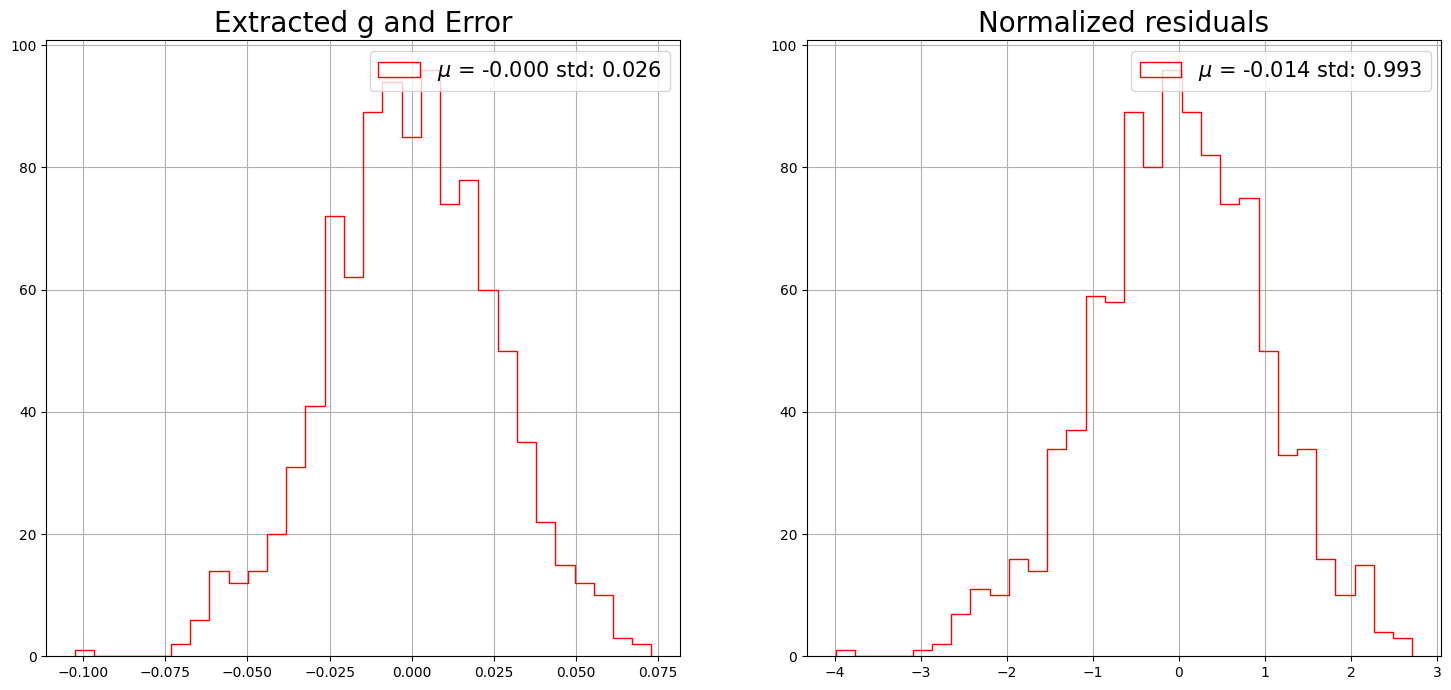

In [22]:
from matplotlib import pyplot as plt

#print(res_norm)
plt.figure(9, figsize = (18,8))
plt.subplot(1,2,1)
plt.title("Extracted g and Error", fontsize = 20)
plt.grid()
plt.hist(Ngravity, bins = 30, histtype = 'step', color = 'red', linestyle = '-', label = f'$\mu$ = {np.mean(Ngravity):.3f} std: {np.std(Ngravity):.3f}')
plt.legend(fontsize = 15, loc = "upper right")
plt.subplot(1,2,2)
plt.title("Normalized residuals", fontsize = 20)
plt.grid()
plt.hist(res_norm, bins = 30, histtype = 'step', color = 'red', linestyle = '-', label = f'$\mu$ = {np.mean(res_norm):.3f} std: {np.std(res_norm):.3f}')
plt.legend(fontsize = 15, loc = "upper right")
plt.savefig(f"residuals_L_{L}.png", bbox_inches = 'tight')

# Fit with D

In [23]:
Ngravity = []
dNgravity = []
ND = []
dND = []

D.setConstant(False)

for i in range(0, Ntoys):
    c.setVal(real_gravity) # reset the value for simulation
    w["nB"].setVal(nB_val)
    D.setVal(Dmu + np.random.normal(loc = 0, scale = Dsigma))  # D detector asymmetry, add a "manual smearing, because the simulation does not account for a generation of D"
    
    for bias, stat in weights.items(): # reset the stat parameters
        w[f"S_{bias}"].setVal(stat)
        print("tot_events:", stat, "set value:", w[f"S_{bias}"].getVal())

    
    pseudo_data = scurve_fit.generate(ROOT.RooArgSet(Z, BiasCategory), ROOT.RooFit.Extended())
    c.setVal(-10)
    result = scurve_fit.fitTo(pseudo_data,
                 ROOT.RooFit.Minimizer("Minuit2","minimize"),
                 ROOT.RooFit.ExternalConstraints(w['Dconstr']),
                 ROOT.RooFit.Strategy(2),
                 ROOT.RooFit.Save(),
                 ROOT.RooFit.PrintLevel(-1),
                 #ROOT.RooFit.Verbose(False),   # disattiva log verboso
                 #ROOT.RooFit.Warnings(False),  # opzionale: disattiva warning
                 ROOT.RooFit.Minos(w['c']))
    # === 8. Risultati
    print("\n=== RISULTATI DEL FIT ===")
    print(f"c     = {c.getVal()*scale.getVal():.4f} ± {c.getError()*scale.getVal():.4f}; [{c.getErrorLo()*scale.getVal()},+{c.getErrorHi()*scale.getVal()}]")
    print(f"scale = {scale.getVal():.4f} ± {scale.getError():.4f}")
    print(f"D     = {D.getVal():.4f} ± {D.getError():.4f}")
    print(f"fit status: {result.status()}")

    if result.status() < 1 and not np.isnan(c.getError()) and c.getError() > 0:
        Ngravity.append(c.getVal()*scale.getVal() - real_gravity*scale.getVal())
        dNgravity.append(c.getError()*scale.getVal())
        ND.append(D.getVal() - Dmu)
        dND.append(D.getError())

# === Normalized Residuals ===
res_norm = (np.array((Ngravity)))/np.array(dNgravity)
Dres_norm = (np.array((ND)))/np.array(dND)

tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9707 ± 0.0461; [-0.04597948717537356,+0.05287504520876453]
scale = 0.1000 ± 0.0000
D     = 0.0248 ± 0.0775
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9596 ± 0.0451; [-0.04514809553572585,+0.057316135686756746]
scale = 0.1000 ± 0.0000
D     = 0.0288 ± 0.0760
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set v


=== RISULTATI DEL FIT ===
c     = -0.9485 ± 0.0508; [-0.04736059195637913,+0.037087977530064445]
scale = 0.1000 ± 0.0000
D     = 0.0123 ± 0.0881
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9871 ± 0.0449; [-0.044507500746312614,+0.048923558437584495]
scale = 0.1000 ± 0.0000
D     = 0.0239 ± 0.0760
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.1477 ± 0.0494; [-0.04327287848460175,+0.04833310313266467]
scale = 0.1000 ± 0.0000
D     = 0.0231 ± 0.0807
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value


=== RISULTATI DEL FIT ===
c     = -0.9818 ± 0.0464; [-0.04695895585732382,+0.04714242266749777]
scale = 0.1000 ± 0.0000
D     = 0.0202 ± 0.0783
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0138 ± 0.0446; [-0.04638395852062311,+0.04387320723713324]
scale = 0.1000 ± 0.0000
D     = 0.0170 ± 0.0763
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9654 ± 0.0448; [-0.04511479640062792,+0.054244375837562565]
scale = 0.1000 ± 0.0000
D     = 0.0269 ± 0.0758
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 


=== RISULTATI DEL FIT ===
c     = -1.0541 ± 0.0483; [-0.04153772698414071,+0.05671620541676471]
scale = 0.1000 ± 0.0000
D     = 0.0317 ± 0.0809
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0706 ± 0.0468; [-0.04732437006910778,+0.047528726476999]
scale = 0.1000 ± 0.0000
D     = 0.0204 ± 0.0796
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0217 ± 0.0456; [-0.048096296468287454,+0.04611696339520327]
scale = 0.1000 ± 0.0000
D     = 0.0180 ± 0.0779
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 15


=== RISULTATI DEL FIT ===
c     = -0.9609 ± 0.0511; [-0.051506066406540534,+0.04081589760130913]
scale = 0.1000 ± 0.0000
D     = 0.0119 ± 0.0849
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9766 ± 0.0477; [-0.047550014787254215,+0.05114412516159831]
scale = 0.1000 ± 0.0000
D     = 0.0226 ± 0.0779
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9789 ± 0.0504; [-0.049989870384167495,+0.04732356117047065]
scale = 0.1000 ± 0.0000
D     = 0.0182 ± 0.0831
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value

...


=== RISULTATI DEL FIT ===
c     = -1.0272 ± 0.0460; [-0.050443607349854286,+0.04594169316352726]
scale = 0.1000 ± 0.0000
D     = 0.0163 ± 0.0770
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0142 ± 0.0491; [-0.05138768500562074,+0.04888088759352602]
scale = 0.1000 ± 0.0000
D     = 0.0183 ± 0.0804
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0062 ± 0.0441; [-0.04342874460569475,+0.04421667582412484]
scale = 0.1000 ± 0.0000
D     = 0.0203 ± 0.0753
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 


=== RISULTATI DEL FIT ===
c     = -1.0133 ± 0.0466; [-0.04941782358167067,+0.046303788570501776]
scale = 0.1000 ± 0.0000
D     = 0.0174 ± 0.0773
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0144 ± 0.0445; [-0.04814251549484577,+0.043979916189977125]
scale = 0.1000 ± 0.0000
D     = 0.0163 ± 0.0758
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9510 ± 0.0456; [-0.047173840780711816,+0.04570794910025008]
scale = 0.1000 ± 0.0000
D     = 0.0190 ± 0.0814
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value


=== RISULTATI DEL FIT ===
c     = -0.9692 ± 0.0471; [-0.0458285530705918,+0.048930474977698916]
scale = 0.1000 ± 0.0000
D     = 0.0224 ± 0.0791
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9877 ± 0.0506; [-0.050276796297057114,+0.050375914173807296]
scale = 0.1000 ± 0.0000
D     = 0.0203 ± 0.0812
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0011 ± 0.0481; [-0.0484628379528231,+0.04742442587323229]
scale = 0.1000 ± 0.0000
D     = 0.0187 ± 0.0799
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 


=== RISULTATI DEL FIT ===
c     = -1.1476 ± 0.0492; [-0.04432808914406187,+0.051433574897371305]
scale = 0.1000 ± 0.0000
D     = 0.0250 ± 0.0812
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9794 ± 0.0489; [-0.04902067021134341,+0.046644295251102044]
scale = 0.1000 ± 0.0000
D     = 0.0189 ± 0.0808
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0428 ± 0.0449; [-0.056600521329493864,+0.044326065383698855]
scale = 0.1000 ± 0.0000
D     = 0.0108 ± 0.0757
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set valu


=== RISULTATI DEL FIT ===
c     = -1.0095 ± 0.0487; [-0.04824494516135295,+0.04820971864047102]
scale = 0.1000 ± 0.0000
D     = 0.0199 ± 0.0820
fit status: 0
[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Minimization --  Including the following constraint terms in minimization: (Dconstr)
[#1] INFO:Minimization -- The global observables are not defined , normalize constraints with respect to the parameters (D,S_-0.1g,S_-0.4g,S_-0.7g,S_-1.0g,S_-1.3g,S_-1.6g,S_-1.9g,c,c_pbarDn_1,c_pbarUp_1,nB,scale,vat_-0.1g,vat_-0.4g,vat_-0.7g,vat_-1.0g,vat_-1.3g,vat_-1.6g,vat_-1.9g)
[#1] INFO:Fitting -- RooAbsPdf::fitTo(scurve_fit) fixing normalization set for coefficient determination to observables in data
[#1] INFO:Fitting -- RooAddition::defaultErrorLevel(nll_scurve_fit_hmaster) Summation contains a RooNLLVar, using its error level
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1

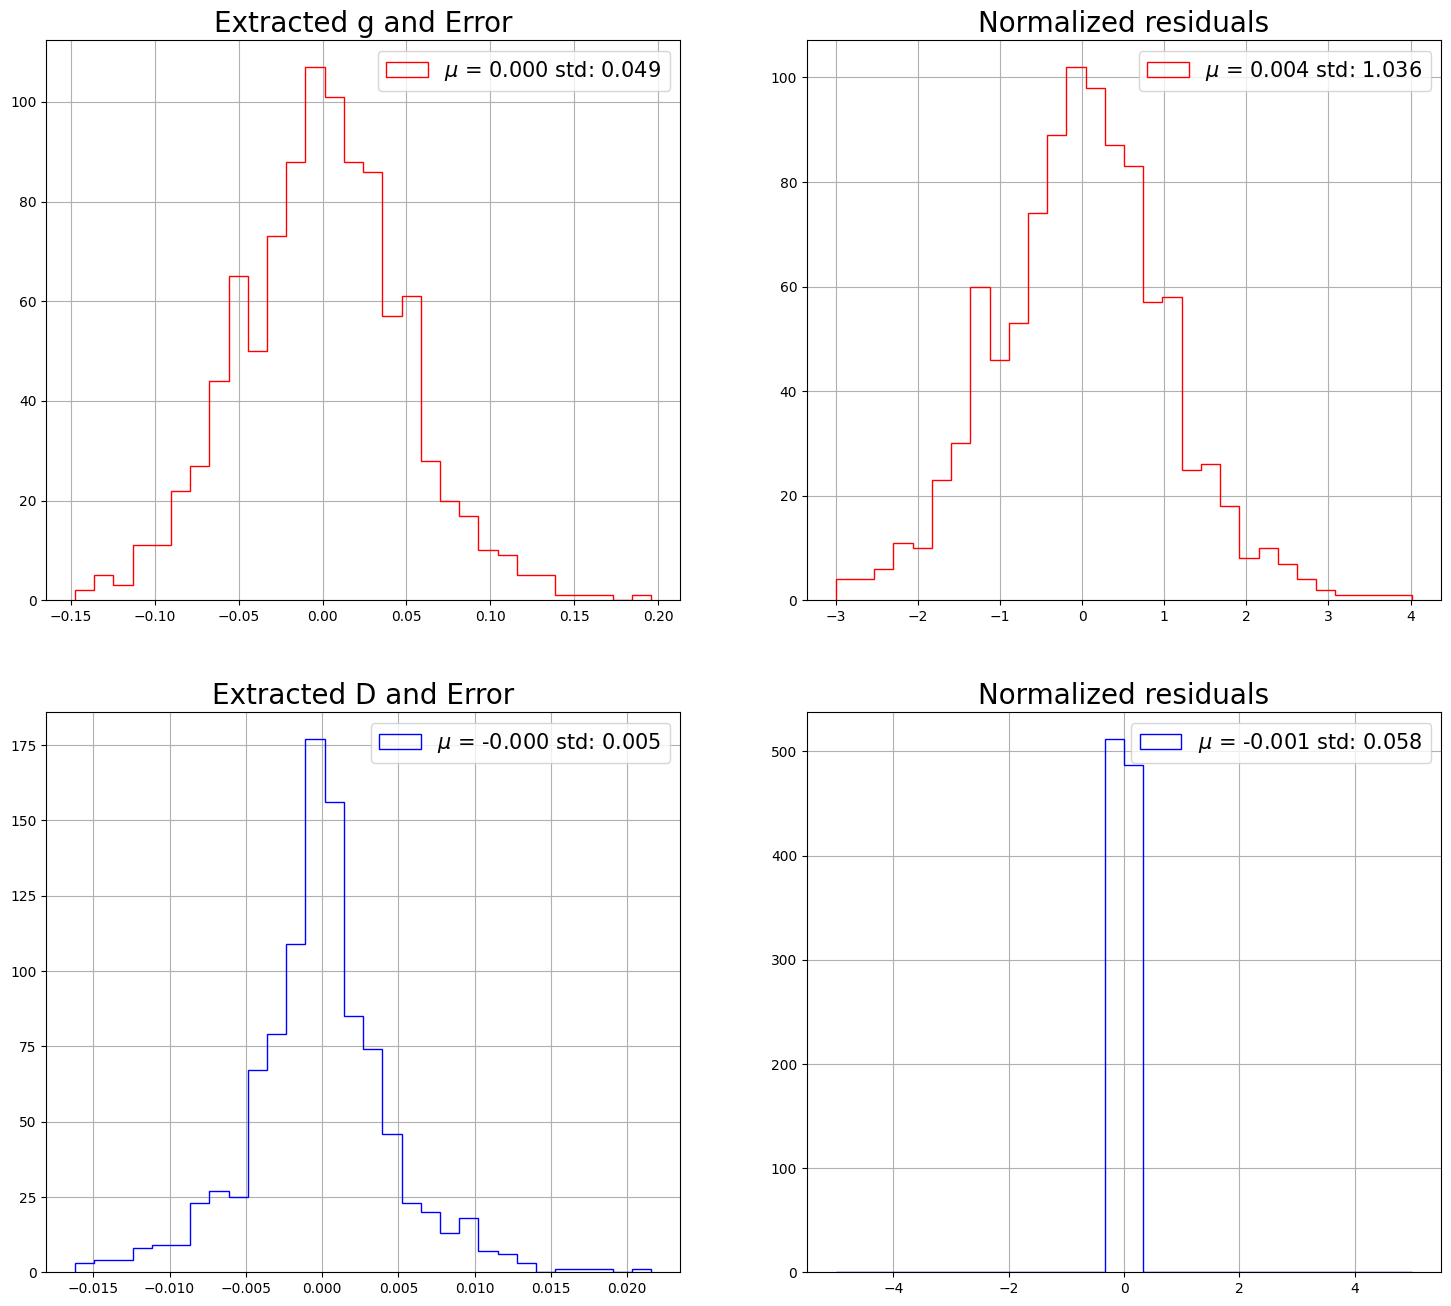

In [24]:
#print(res_norm)
plt.figure(10, figsize = (18,16))
plt.subplot(2,2,1)
plt.title("Extracted g and Error", fontsize = 20)
plt.grid()
plt.hist(Ngravity, bins = 30, histtype = 'step', color = 'red', linestyle = '-', label = f'$\mu$ = {np.mean(Ngravity):.3f} std: {np.std(Ngravity):.3f}')
plt.legend(fontsize = 15,  loc = "upper right")
plt.subplot(2,2,2)
plt.title("Normalized residuals", fontsize = 20)
plt.grid()
plt.hist(res_norm, bins = 30, histtype = 'step', color = 'red', linestyle = '-', label = f'$\mu$ = {np.mean(res_norm):.3f} std: {np.std(res_norm):.3f}')
plt.legend(fontsize = 15, loc = "upper right")

#plt.figure(11, figsize = (18,8))
plt.subplot(2,2,3)
plt.title("Extracted D and Error", fontsize = 20)
plt.grid()
plt.hist(ND, bins = 30, histtype = 'step', color = 'blue', linestyle = '-', label = f'$\mu$ = {np.mean(ND):.3f} std: {np.std(ND):.3f}')
plt.legend(fontsize = 15,  loc = "upper right")
plt.subplot(2,2,4)
plt.title("Normalized residuals", fontsize = 20)
plt.grid()
plt.hist(Dres_norm, bins = 30, range = (-5, 5), histtype = 'step', color = 'blue', linestyle = '-', label = f'$\mu$ = {np.mean(Dres_norm):.3f} std: {np.std(Dres_norm):.3f}')
plt.legend(fontsize = 15, loc = "upper right")

plt.savefig(f"residuals_D_L_{L}.png", bbox_inches = 'tight')